In [1]:
import os
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

In [102]:
def load_metrics(root_dir):
    data = []
    root = Path(root_dir)
    
    # Iterate through model directories
    for model_dir in root.iterdir():
        if not model_dir.is_dir():
            continue
            
        # format: modelName_datasetName
        parts = model_dir.name.split('_')
        model_name = "_".join(parts[:-1])
        dataset = parts[-1]
        
        # Iterate through k directories
        for k_dir in model_dir.iterdir():
            if not k_dir.is_dir():
                continue
            
            k_val = int(k_dir.name[1:]) # e.g., "k2"
            json_path = k_dir / "metrics.json"
            
            if json_path.exists():
                with open(json_path, 'r') as f:
                    metrics = json.load(f)
                    metrics = metrics['test_metrics']
                    # Add metadata to the metrics dict
                    metrics.update({
                        'model': model_name,
                        'dataset': dataset,
                        'k': k_val
                    })
                    data.append(metrics)
    df = pd.DataFrame(data)
    df = df.sort_values(by=['dataset','model','k'], ascending=[True, True, True])            
    return df
# 2_classes_label_leakage
df_2cls_ll = load_metrics('../results/two_classes/label_leakage/')
# 2_classes_no_label_leakage
df_2cls_nll = load_metrics('../results/two_classes/no_label_leakage/')
# 3_classes_label_leakage
df_3cls_ll = load_metrics('../results/three_classes/label_leakage/')
# 3_class_no_label_leakage
df_3cls_nll = load_metrics('../results/three_classes/no_label_leakage/')

In [103]:
#df_2cls_ll= df_2cls_ll.sort_values(by=['dataset','model','k'], ascending=[True, True, True])
df_2cls_ll

,Accuracy,Precision,Recall,F1-Score,AUROC,model,dataset,k
21,0.554054,0.478632,0.554054,0.484293,0.518774,fuzzy_fuzzy_only,BRComposite,2
18,0.554054,0.478632,0.554054,0.484293,0.518008,fuzzy_fuzzy_only,BRComposite,3
19,0.554054,0.478632,0.554054,0.484293,0.518774,fuzzy_fuzzy_only,BRComposite,4
20,0.554054,0.478632,0.554054,0.484293,0.518774,fuzzy_fuzzy_only,BRComposite,5
30,0.554054,0.478632,0.554054,0.484293,0.518774,fuzzy_fuzzy_only,BRComposite,6
...,...,...,...,...,...,...,...,...
214,0.986486,0.986780,0.986486,0.986442,0.993103,fuzzy_paper_gcn,Composite,15
207,0.986486,0.986780,0.986486,0.986442,0.993103,fuzzy_paper_gcn,Composite,16
202,0.986486,0.986780,0.986486,0.986442,1.000000,fuzzy_paper_gcn,Composite,17
205,0.986486,0.986780,0.986486,0.986442,1.000000,fuzzy_paper_gcn,Composite,18


In [104]:
df_2cls_nll

,Accuracy,Precision,Recall,F1-Score,AUROC,model,dataset,k
21,0.554054,0.478632,0.554054,0.484293,0.518774,fuzzy_fuzzy_only,BRComposite,2
18,0.554054,0.478632,0.554054,0.484293,0.518774,fuzzy_fuzzy_only,BRComposite,3
19,0.554054,0.478632,0.554054,0.484293,0.518774,fuzzy_fuzzy_only,BRComposite,4
20,0.554054,0.478632,0.554054,0.484293,0.518774,fuzzy_fuzzy_only,BRComposite,5
30,0.554054,0.478632,0.554054,0.484293,0.518774,fuzzy_fuzzy_only,BRComposite,6
...,...,...,...,...,...,...,...,...
214,1.000000,1.000000,1.000000,1.000000,1.000000,fuzzy_paper_gcn,Composite,15
207,1.000000,1.000000,1.000000,1.000000,1.000000,fuzzy_paper_gcn,Composite,16
202,1.000000,1.000000,1.000000,1.000000,1.000000,fuzzy_paper_gcn,Composite,17
205,0.986486,0.986780,0.986486,0.986442,1.000000,fuzzy_paper_gcn,Composite,18


In [105]:
df_3cls_ll

,Accuracy,Precision,Recall,F1-Score,AUROC,model,dataset,k
21,0.324324,0.359108,0.324324,0.303635,0.513262,fuzzy_fuzzy_only,BRComposite,2
18,0.324324,0.359108,0.324324,0.303635,0.513262,fuzzy_fuzzy_only,BRComposite,3
19,0.324324,0.359108,0.324324,0.303635,0.512152,fuzzy_fuzzy_only,BRComposite,4
20,0.324324,0.359108,0.324324,0.303635,0.512152,fuzzy_fuzzy_only,BRComposite,5
30,0.324324,0.359108,0.324324,0.303635,0.512152,fuzzy_fuzzy_only,BRComposite,6
...,...,...,...,...,...,...,...,...
214,0.554054,0.487833,0.554054,0.500396,0.724395,fuzzy_paper_gcn,Composite,15
207,0.567568,0.524058,0.567568,0.508992,0.743751,fuzzy_paper_gcn,Composite,16
202,0.500000,0.469112,0.500000,0.478892,0.715698,fuzzy_paper_gcn,Composite,17
205,0.527027,0.504093,0.527027,0.511101,0.733264,fuzzy_paper_gcn,Composite,18


In [106]:
df_3cls_nll

,Accuracy,Precision,Recall,F1-Score,AUROC,model,dataset,k
21,0.324324,0.359108,0.324324,0.303635,0.512152,fuzzy_fuzzy_only,BRComposite,2
18,0.324324,0.359108,0.324324,0.303635,0.512152,fuzzy_fuzzy_only,BRComposite,3
19,0.324324,0.359108,0.324324,0.303635,0.513262,fuzzy_fuzzy_only,BRComposite,4
20,0.324324,0.359108,0.324324,0.303635,0.513262,fuzzy_fuzzy_only,BRComposite,5
30,0.324324,0.359108,0.324324,0.303635,0.513262,fuzzy_fuzzy_only,BRComposite,6
...,...,...,...,...,...,...,...,...
291,0.608108,0.576833,0.608108,0.562202,0.731093,fuzzy_paper_gcn,Composite,15
284,0.581081,0.546091,0.581081,0.533130,0.747646,fuzzy_paper_gcn,Composite,16
279,0.567568,0.544833,0.567568,0.552619,0.770642,fuzzy_paper_gcn,Composite,17
282,0.513514,0.506099,0.513514,0.507733,0.756628,fuzzy_paper_gcn,Composite,18


In [107]:
for i in df_2cls_ll['dataset'].unique():
    print(i)

BRComposite
Composite


In [119]:
def plot_k_comparison(df, metric_name='Accuracy'):
    datasets = df['dataset'].unique()
    for ds in datasets:
        dff = df[df['dataset'] == ds]
        plt.figure(figsize=(10, 6))
        sns.barplot(data=dff, x='k', y=metric_name, hue='model')
        plt.title(f'{metric_name} Comparison across different k values on {ds} dataset')
        plt.ylabel(metric_name.capitalize())
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()

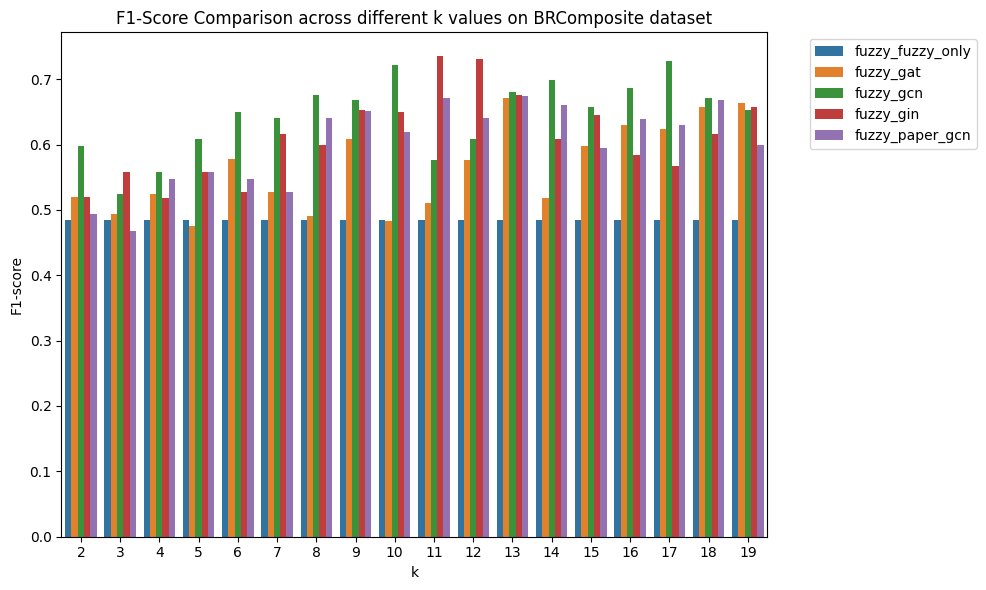

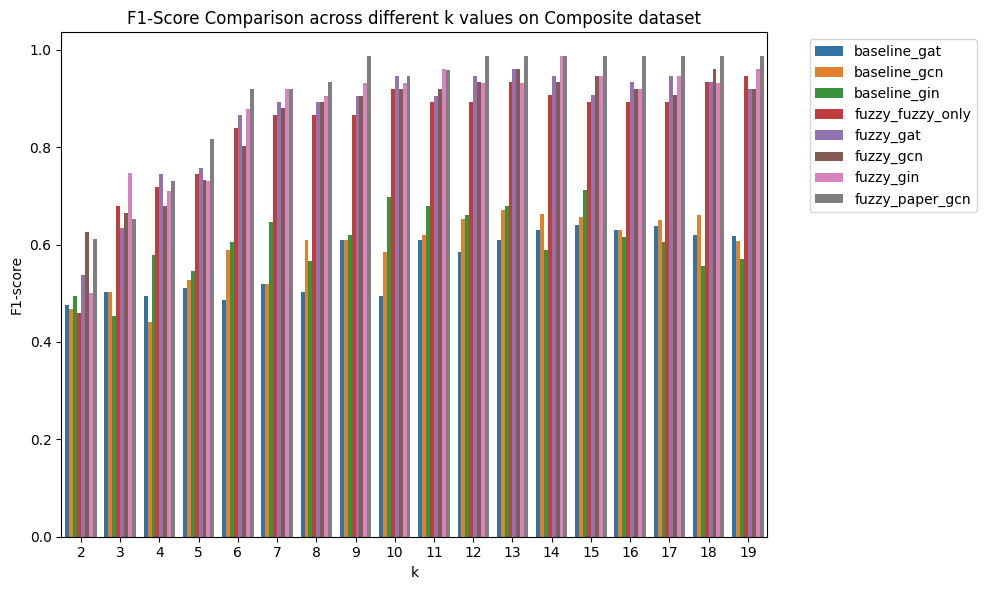

In [120]:
plot_k_comparison(df_2cls_ll, 'F1-Score')

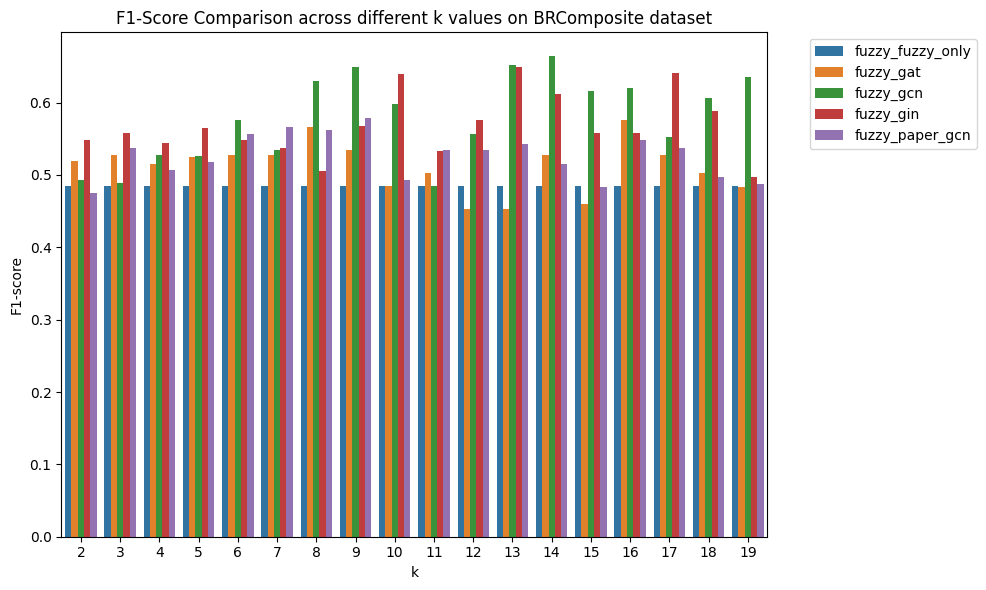

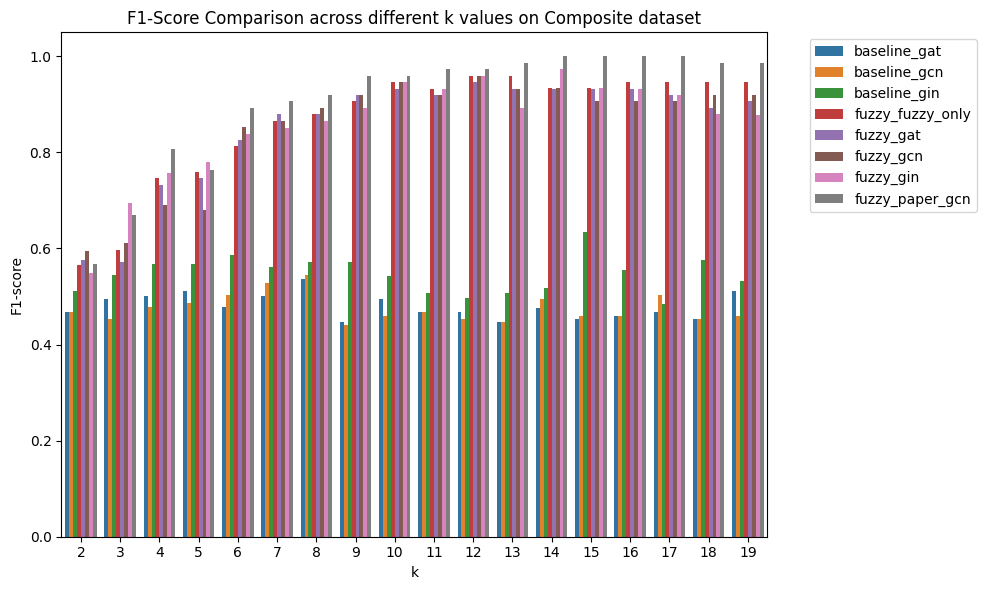

In [121]:
plot_k_comparison(df_2cls_nll,'F1-Score')

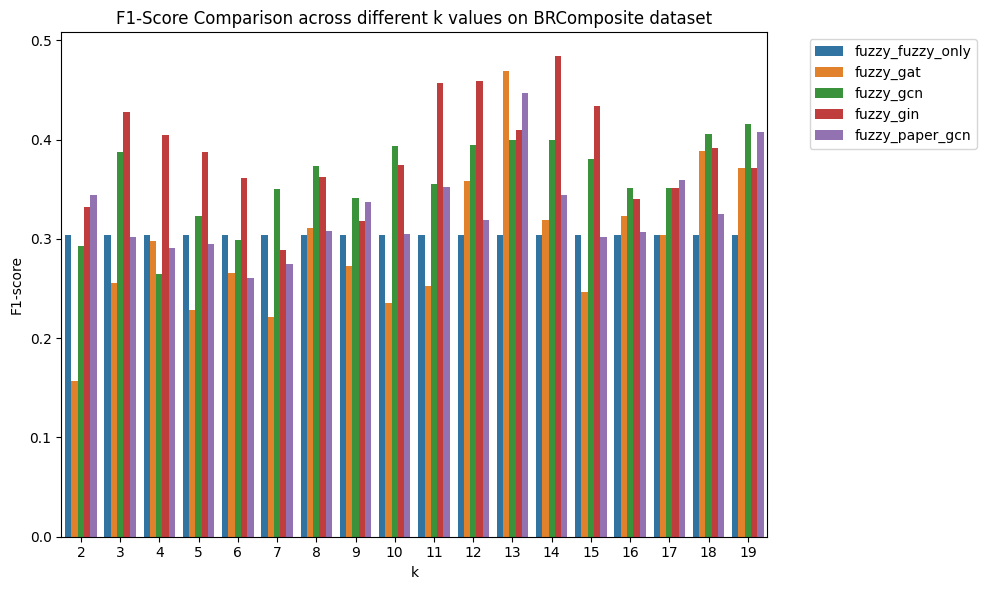

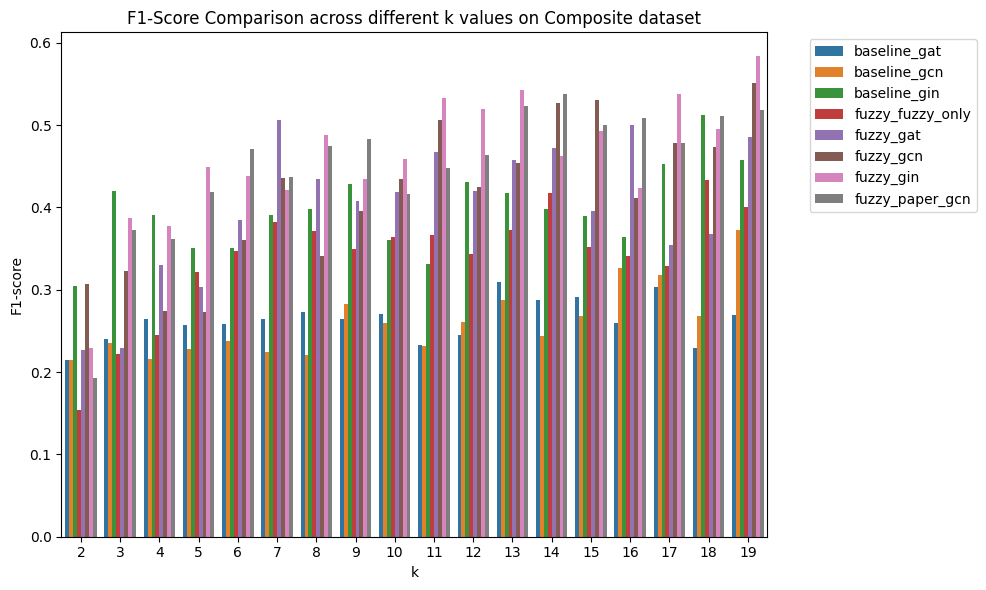

In [126]:
plot_k_comparison(df_3cls_ll, 'F1-Score')

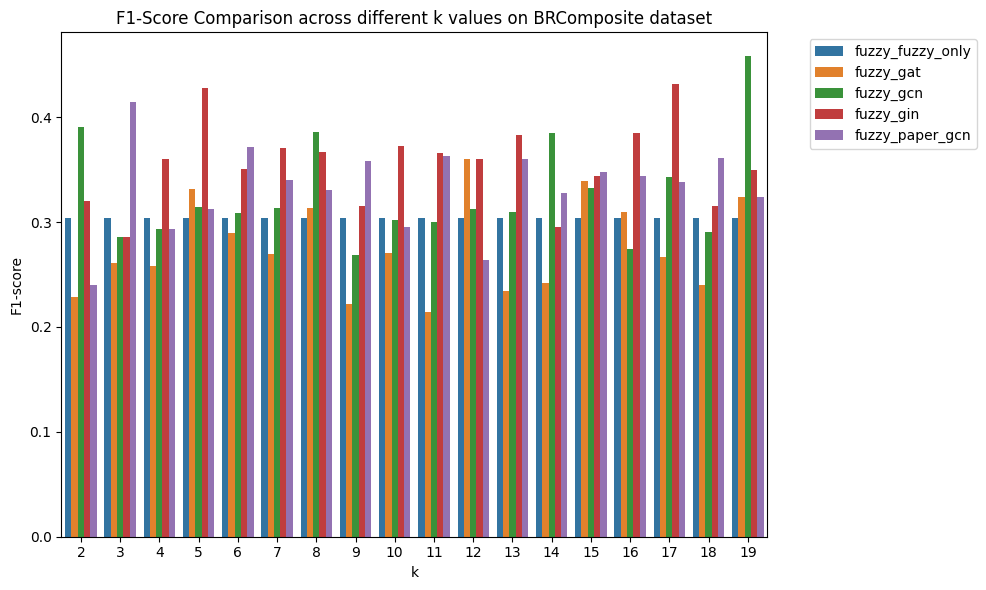

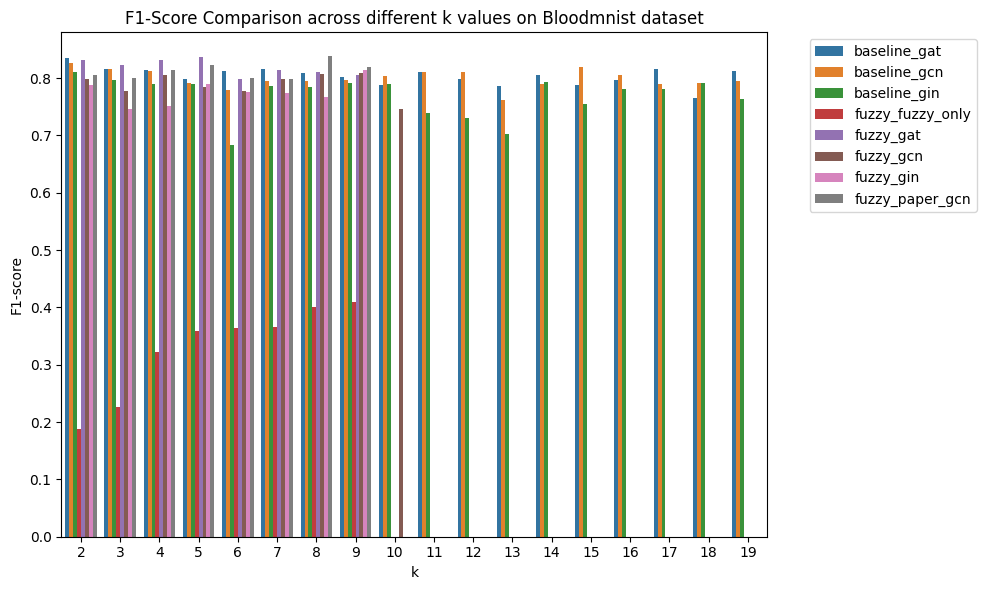

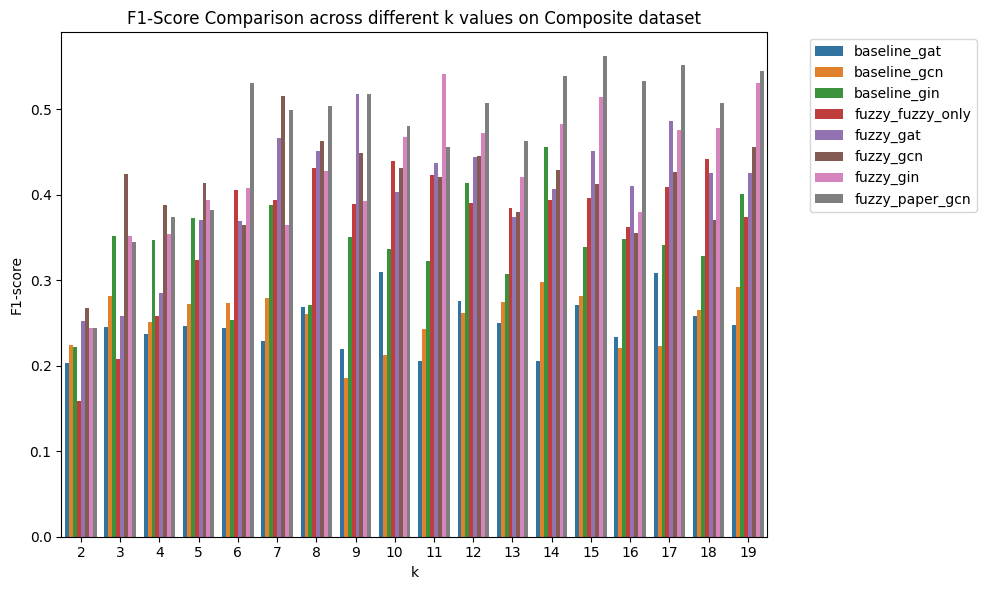

In [127]:
plot_k_comparison(df_3cls_nll, 'F1-Score')

In [114]:
def plot_best_models(df, metric_name='F1-Score'):
    for ds in df['dataset'].unique():
        dff = df[df['dataset']==ds]
        idx = dff.groupby(['model', 'dataset'])[metric_name].idxmax()
        best_df = dff.loc[idx]
        
        plt.figure(figsize=(10, 6))
        sns.barplot(data=best_df, x='model', y=metric_name, palette='viridis')
        
        for i, (index, row) in enumerate(best_df.iterrows()):
            # Use the actual dataframe value directly via the index
            val = row[metric_name]
            
            # Label for k at the top
            plt.text(i, val, f"k={row['k']}", ha='center', va='bottom', fontweight='bold')
            
            # Label for metric in the middle
            plt.text(i, val / 2, f"{val:.4f}", 
                     ha='center', va='center', 
                     color='white', fontweight='bold')
            
        plt.title(f'Comparison of Best Models ({metric_name}) on {ds}')
        plt.show()

/var/folders/ft/2nftg5q91n5dhpf5dtts4gkm0000gn/T/ipykernel_66094/179046885.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=best_df, x='model', y=metric_name, palette='viridis')


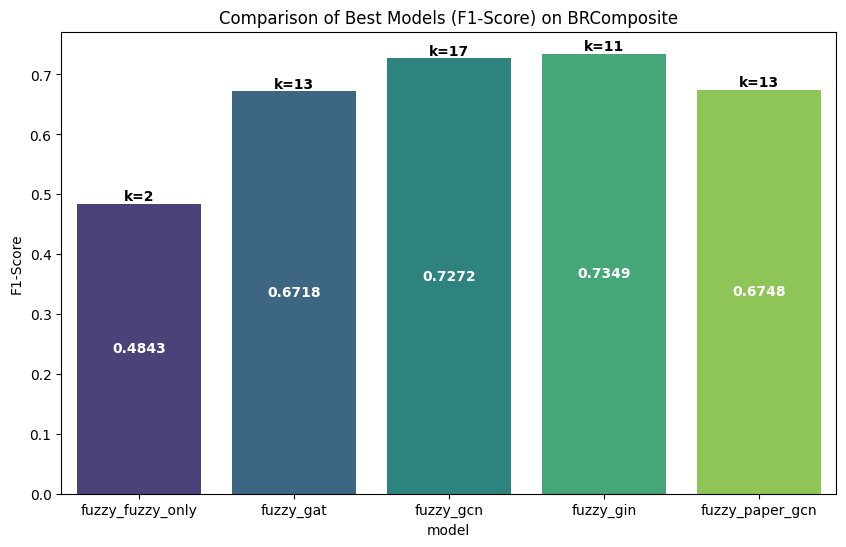

/var/folders/ft/2nftg5q91n5dhpf5dtts4gkm0000gn/T/ipykernel_66094/179046885.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=best_df, x='model', y=metric_name, palette='viridis')


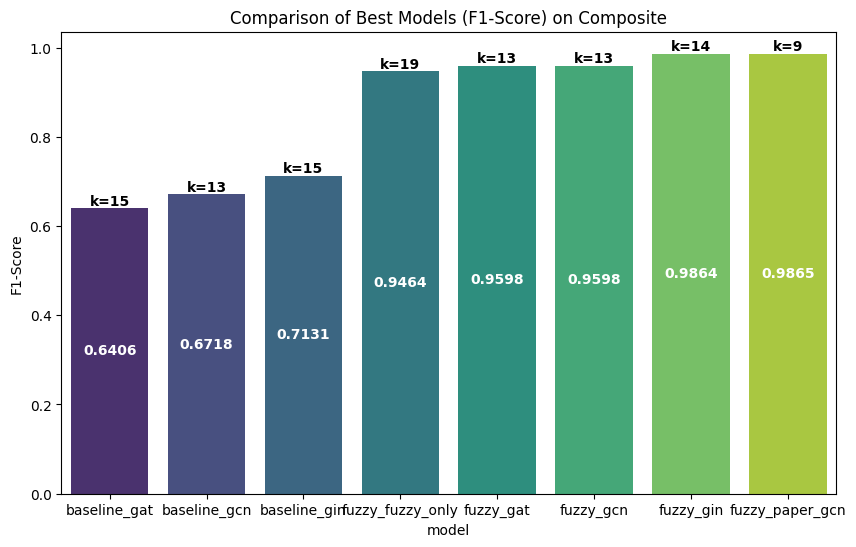

In [115]:
plot_best_models(df_2cls_ll)

/var/folders/ft/2nftg5q91n5dhpf5dtts4gkm0000gn/T/ipykernel_66094/179046885.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=best_df, x='model', y=metric_name, palette='viridis')


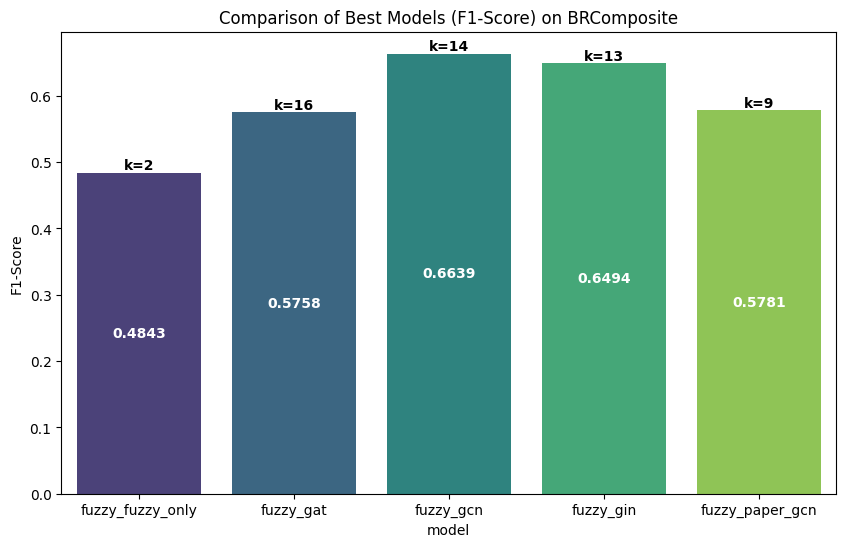

/var/folders/ft/2nftg5q91n5dhpf5dtts4gkm0000gn/T/ipykernel_66094/179046885.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=best_df, x='model', y=metric_name, palette='viridis')


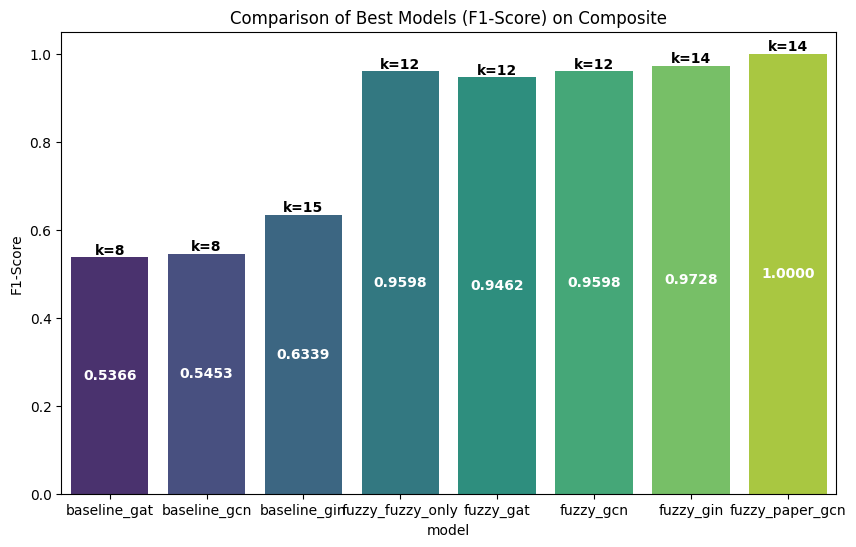

In [116]:
plot_best_models(df_2cls_nll)

/var/folders/ft/2nftg5q91n5dhpf5dtts4gkm0000gn/T/ipykernel_66094/179046885.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=best_df, x='model', y=metric_name, palette='viridis')


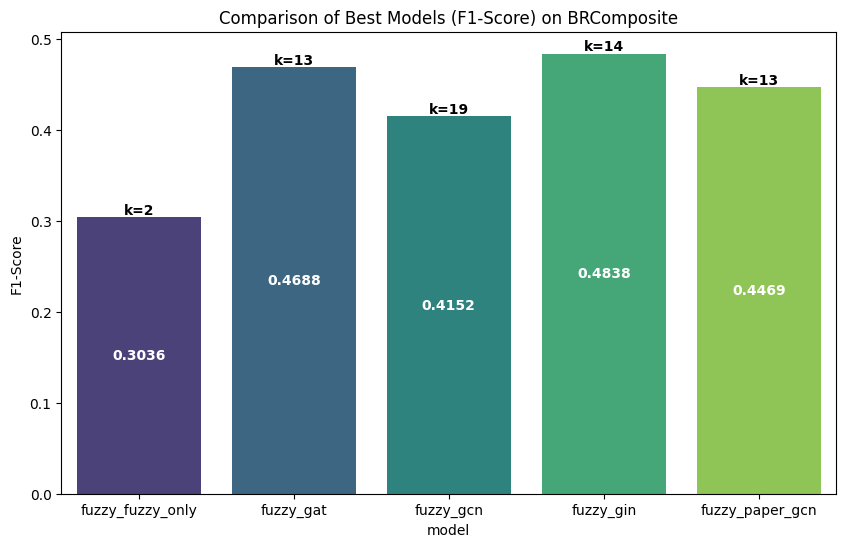

/var/folders/ft/2nftg5q91n5dhpf5dtts4gkm0000gn/T/ipykernel_66094/179046885.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=best_df, x='model', y=metric_name, palette='viridis')


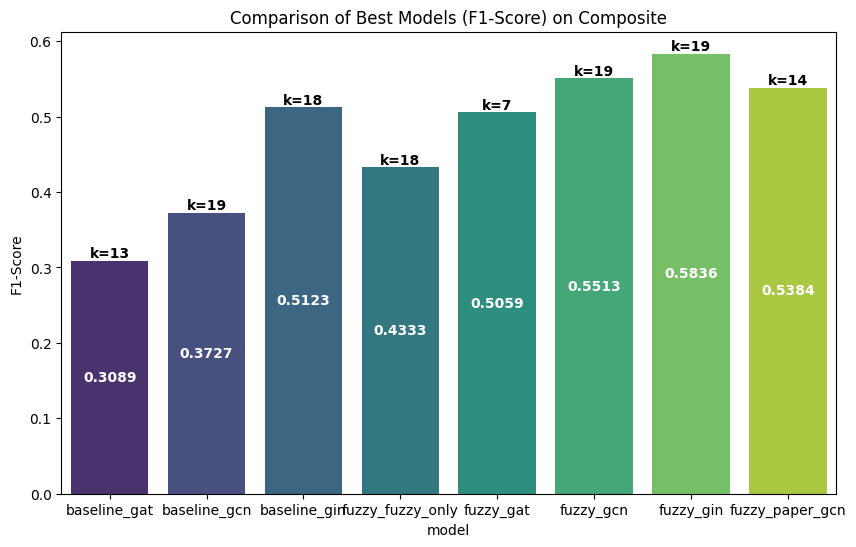

In [117]:
plot_best_models(df_3cls_ll)

/var/folders/ft/2nftg5q91n5dhpf5dtts4gkm0000gn/T/ipykernel_66094/179046885.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=best_df, x='model', y=metric_name, palette='viridis')


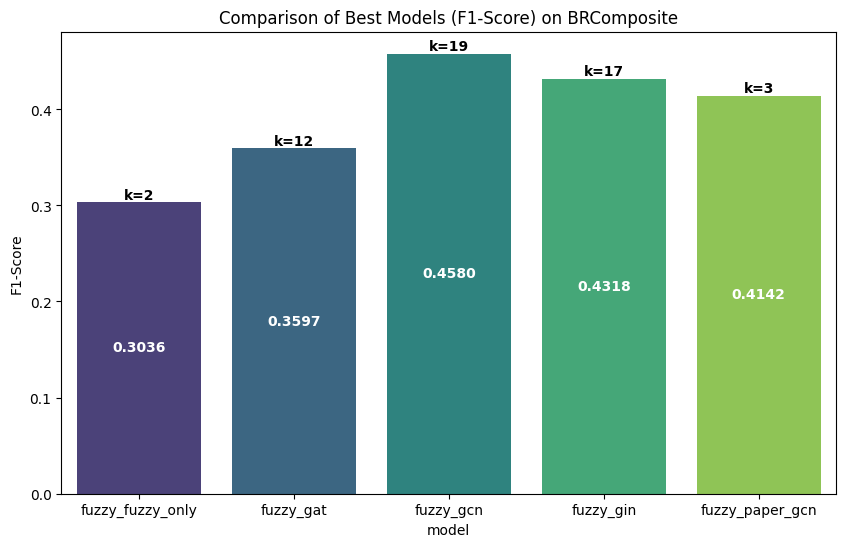

/var/folders/ft/2nftg5q91n5dhpf5dtts4gkm0000gn/T/ipykernel_66094/179046885.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=best_df, x='model', y=metric_name, palette='viridis')


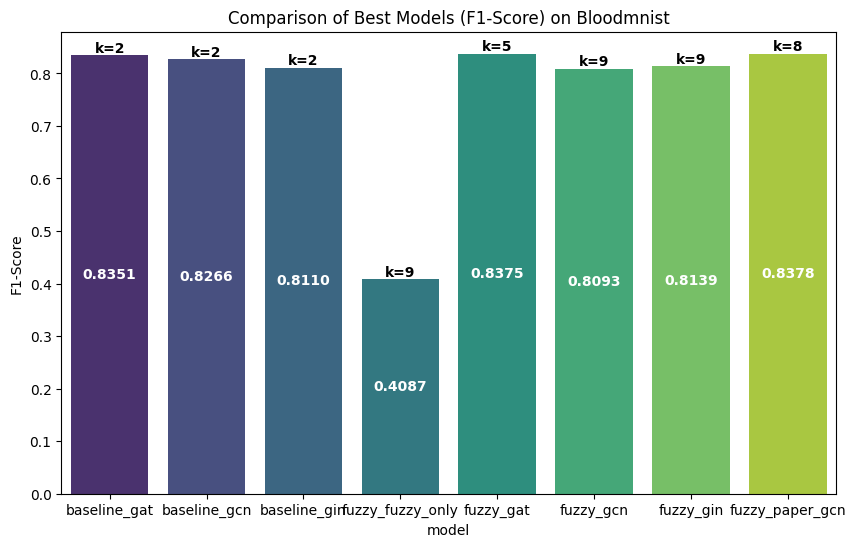

/var/folders/ft/2nftg5q91n5dhpf5dtts4gkm0000gn/T/ipykernel_66094/179046885.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=best_df, x='model', y=metric_name, palette='viridis')


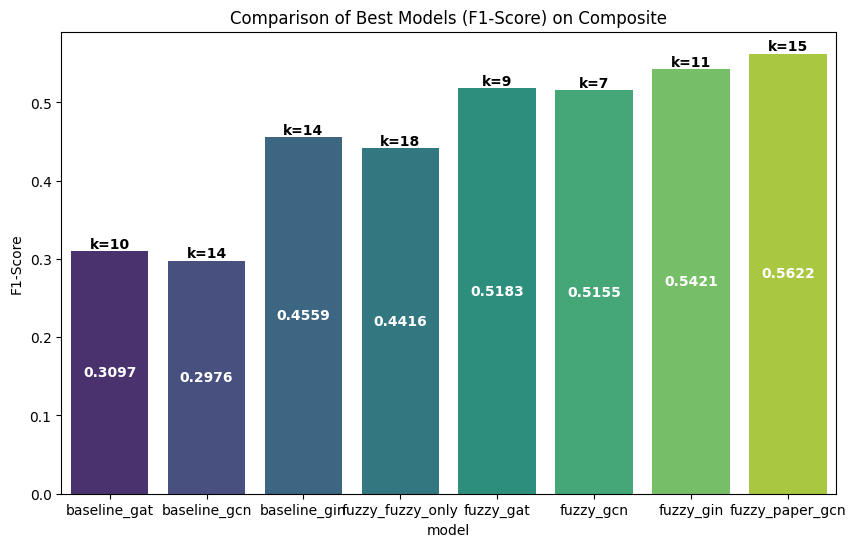

In [118]:
plot_best_models(df_3cls_nll)